# Project Setup: RL-Orchestrated Multi-Agent Deepfake Detection Framework

This section initializes the environment for training the **Spatial Video Agent** using EfficientNet-B0 on the FakeAVCeleb dataset. It handles dependencies, logging, and hardware acceleration settings.

In [20]:
# Install required libraries
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q efficientnet_pytorch albumentations wandb

In [21]:
import os
import sys
import time
import random
import logging

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from efficientnet_pytorch import EfficientNet

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

def set_seed(seed: int = 42):
    """Sets random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True # Enabled for T4 performance optimization
    logger.info(f"Random seed set to: {seed}")

set_seed(42)

# GPU Detection and Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == 'cuda':
    gpu_props = torch.cuda.get_device_properties(0)
    logger.info(f"GPU Detected: {gpu_props.name}")
    logger.info(f"VRAM Capacity: {gpu_props.total_memory / 1024**2:.0f} MB")
    logger.info(f"Compute Capability: {gpu_props.major}.{gpu_props.minor}")
else:
    logger.warning("No GPU detected. Training will be extremely slow on CPU.")

## Google Drive and Dataset Loading

This section handles the connection to Google Drive and performs an initial inspection of the FakeAVCeleb dataset to ensure data integrity and provide class distribution statistics.

In [22]:
from google.colab import drive
from pathlib import Path
import glob

# 1. Mount Google Drive
try:
    drive.mount('/content/drive')
    logger.info("Google Drive mounted successfully.")
except Exception as e:
    logger.error(f"Failed to mount Google Drive: {e}")

# 2. Configuration
# Updated to point to the pre-extracted 'frames' directory for spatial analysis
DATASET_PATH = Path('/content/drive/MyDrive/FakeAVCeleb_v1.2/frames')

def inspect_dataset(root_path: Path):
    if not root_path.exists():
        logger.error(f"Path not found: {root_path}")
        return

    logger.info(f"Inspecting dataset at: {root_path}")

    # Looking for images in the frames folder
    extensions = ['*.jpg', '*.jpeg', '*.png']

    image_files = []
    for ext in extensions:
        image_files.extend(list(root_path.rglob(ext)))

    total_samples = len(image_files)

    real_samples = [v for v in image_files if any("RealVideo" in part for part in v.parts)]
    fake_samples = [v for v in image_files if any("FakeVideo" in part for part in v.parts)]

    print("\n" + "="*40)
    print(" FRAME DATASET STATISTICS ")
    print("="*40)
    print(f"Total Frames Found:  {total_samples}")
    print(f"Real Frames Count:   {len(real_samples)}")
    print(f"Fake Frames Count:   {len(fake_samples)}")
    print("-"*40)

# Execute inspection
inspect_dataset(DATASET_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 FRAME DATASET STATISTICS 
Total Frames Found:  21564
Real Frames Count:   1000
Fake Frames Count:   20564
----------------------------------------


In [23]:
import os
import logging
from pathlib import Path

# Ensure logger is accessible
logger = logging.getLogger(__name__)

# Defining OUTPUT_DIR to resolve the NameError
OUTPUT_DIR = Path('/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"Output directory set to: {OUTPUT_DIR}")

## Dataset Preparation

This section generates the metadata manifests required for training. It performs a stratified split to ensure the distribution of Real vs. Fake videos is consistent across the training, validation, and testing sets.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

def prepare_dataset_csvs(root_path: Path, output_dir: Path, split_ratio=(0.7, 0.15, 0.15)):
    logger.info("Starting metadata generation for frames...")

    # Target pre-extracted frames (images)
    extensions = ['*.jpg', '*.jpeg', '*.png']
    image_data = []

    for ext in extensions:
        for img_path in root_path.rglob(ext):
            # Labeling based on folder convention
            label = 0 if any("RealVideo" in part for part in img_path.parts) else 1
            image_data.append({
                'video_path': str(img_path),
                'label': label,
                'category': img_path.parent.name
            })

    df = pd.DataFrame(image_data)

    if df.empty:
        logger.error(f"No frames found at {root_path}. Check directory structure.")
        return

    # Save metadata
    output_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_dir / 'metadata.csv', index=False)

    # Stratified Split
    train_df, temp_df = train_test_split(
        df, test_size=(split_ratio[1] + split_ratio[2]),
        stratify=df['label'], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5,
        stratify=temp_df['label'], random_state=42
    )

    train_df.to_csv(output_dir / 'train.csv', index=False)
    val_df.to_csv(output_dir / 'val.csv', index=False)
    test_df.to_csv(output_dir / 'test.csv', index=False)

    print(f"Manifests created at {output_dir}")
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Run with updated DATASET_PATH (pointing to /frames)
prepare_dataset_csvs(DATASET_PATH, OUTPUT_DIR)

Manifests created at /content/drive/MyDrive/FakeAVCeleb_v1.2/manifests
Train: 15094 | Val: 3235 | Test: 3235


## Data Preprocessing and Augmentation

This section defines the transformation pipelines using `albumentations`. It includes a heavy augmentation suite for training to prevent overfitting and a standard pipeline for evaluation.

In [25]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ImageNet statistics for normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# Training Augmentation Pipeline
train_transforms = A.Compose([
    # For RandomResizedCrop, Albumentations 1.4+ accepts 'size' as a tuple (h, w)
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.3),

    # Color and Lighting
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.RandomGamma(gamma_limit=(80, 120), p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
    ], p=0.5),

    # Blurs and Noise
    A.OneOf([
        A.MotionBlur(p=1.0),
        A.GaussianBlur(p=1.0),
        # Fixed: GaussNoise now uses 'std_range' instead of 'var_limit'
        A.GaussNoise(std_range=(10.0 / 255, 50.0 / 255), p=1.0),
    ], p=0.3),

    # Fixed: ImageCompression now uses 'quality_range' instead of lower/upper
    A.ImageCompression(quality_range=(60, 100), p=0.3),

    # Weather and Shadows
    A.RandomShadow(p=0.2),
    A.RandomFog(p=0.1),
    A.RandomRain(p=0.1),

    # Fixed: CoarseDropout arguments updated; 'fill_value' is removed as it is now implicit or handled differently
    A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 16), hole_width_range=(8, 16), p=0.2),

    # Normalization and Tensor Conversion
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# Validation and Test Pipeline (Deterministic)
val_test_transforms = A.Compose([
    # Fixed: Resize requires height and width as explicit arguments in this version
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

logger.info("Preprocessing pipelines initialized and verified for the latest Albumentations API.")
print(f"Target Resolution: {IMG_SIZE}x{IMG_SIZE}")
print(f"Training Pipeline enabled with {len(train_transforms)} transformation blocks.")

Target Resolution: 224x224
Training Pipeline enabled with 12 transformation blocks.


## Custom PyTorch Dataset

This section defines the `DeepfakeDataset` class, which manages data loading from the CSV manifests and ensures that augmentations are applied correctly to each frame.

In [26]:
import cv2
import torch
from torch.utils.data import Dataset
import pandas as pd

class DeepfakeDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        """
        Args:
            csv_file (str): Path to the train/val/test csv file.
            transform (callable, optional): Albumentations transform pipeline.
        """
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        logger.info(f"Dataset initialized with {len(self.data)} samples.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['video_path']
        label = self.data.iloc[idx]['label']

        try:
            image = cv2.imread(img_path)
            if image is None:
                raise FileNotFoundError(f"Image missing: {img_path}")

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']

            return image, torch.tensor(label, dtype=torch.long)

        except Exception as e:
            logger.debug(f"Error index {idx}: {e}")
            dummy_img = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            return dummy_img, torch.tensor(label, dtype=torch.long)

In [27]:
import cv2
import torch
import random
import logging
import pandas as pd
from torch.utils.data import Dataset

logger = logging.getLogger(__name__)

class DeepfakeDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.bad_images_log = "bad_images.txt"
        logger.info(f"Dataset initialized with {len(self.data)} samples.")

    def __len__(self):
        return len(self.data)

    def _load_image(self, img_path):
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Corrupt or missing image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 4:
            image = image[:, :, :3]
        return image

    def __getitem__(self, idx):
        attempts = 0
        max_attempts = 10
        current_idx = idx
        while attempts < max_attempts:
            img_path = self.data.iloc[current_idx]['video_path']
            label = self.data.iloc[current_idx]['label']
            try:
                image = self._load_image(img_path)
                if self.transform:
                    image = self.transform(image=image)['image']
                return image, torch.tensor(label, dtype=torch.long)
            except Exception as e:
                attempts += 1
                worker_info = torch.utils.data.get_worker_info()
                worker_id = worker_info.id if worker_info else "Main"
                logger.warning(f"[Worker {worker_id}] Error loading {img_path}: {e}")
                with open(self.bad_images_log, "a") as f:
                    f.write(f"{img_path}\n")
                current_idx = random.randint(0, len(self.data) - 1)
        return torch.zeros((3, 224, 224)), torch.tensor(label, dtype=torch.long)

## PyTorch DataLoaders

This section initializes the DataLoaders for all splits. It uses optimized settings for Google Colab, including automatic worker detection and memory pinning for faster GPU transfer.

In [28]:
import multiprocessing

# Configuration
BATCH_SIZE = 32

# Automatically determine optimal workers (typically num_cpus)
NUM_WORKERS = multiprocessing.cpu_count()

# Initialize Datasets
train_dataset = DeepfakeDataset(csv_file=OUTPUT_DIR / 'train.csv', transform=train_transforms)
val_dataset = DeepfakeDataset(csv_file=OUTPUT_DIR / 'val.csv', transform=val_test_transforms)
test_dataset = DeepfakeDataset(csv_file=OUTPUT_DIR / 'test.csv', transform=val_test_transforms)

# Create Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

logger.info(f"DataLoaders created with Batch Size: {BATCH_SIZE} and Workers: {NUM_WORKERS}")

# Verify Batch Shapes
images, labels = next(iter(train_loader))
print("\n" + "="*40)
print(" DATALOADER VERIFICATION ")
print("="*40)
print(f"Batch Image Shape: {images.shape}") # Expecting [batch, 3, 224, 224]
print(f"Batch Label Shape: {labels.shape}")
print("="*40)


 DATALOADER VERIFICATION 
Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Label Shape: torch.Size([32])


In [29]:
import torch
from torch.utils.data import DataLoader

# Safest configuration for Google Drive + Colab T4
NUM_WORKERS = 2
_BATCH_SIZE = globals().get('BATCH_SIZE', 32)

# Ensure we use the global variables defined in earlier cells
if 'train_dataset' not in globals():
    print("❌ 'train_dataset' is missing. Re-running initialization...")
    current_transform = globals().get('train_transforms', None)
    if 'DeepfakeDataset' in globals() and 'OUTPUT_DIR' in globals():
        train_dataset = DeepfakeDataset(csv_file=OUTPUT_DIR / 'train.csv', transform=current_transform)
    else:
        print("❌ Critical: Dataset class or OUTPUT_DIR not found. Please run previous cells.")

train_loader = DataLoader(
    train_dataset, batch_size=_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True, prefetch_factor=2, timeout=30
)

print("Running DataLoader stability sanity check (20 batches)...")
try:
    current_model = globals().get('model', None)
    if current_model is not None:
        current_model.eval()
        with torch.no_grad():
            for i, (imgs, lbls) in enumerate(train_loader):
                if i >= 20: break
        print("✅ Sanity check passed. DataLoader is stable.")
    else:
        print("⚠️ Model not initialized yet. DataLoader prepared but sanity check skipped.")
except Exception as e:
    print(f"❌ Sanity check failed: {e}")

Running DataLoader stability sanity check (20 batches)...
⚠️ Model not initialized yet. DataLoader prepared but sanity check skipped.


## Model Architecture: Spatial Video Agent

This section defines the core architecture using **EfficientNet-B0**. We employ transfer learning by initializing with ImageNet weights and customising the classification head for deepfake detection (binary classification).

In [30]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def initialize_spatial_agent(num_classes=1, freeze_backbone=True):
    # Load pretrained EfficientNet-B0
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    # Freeze backbone layers
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        logger.info("Model backbone frozen.")

    # Replace the classifier head
    # EfficientNet-B0 classifier input features: 1280
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

def unfreeze_model(model, unfreeze_all=True, layers_to_unfreeze=0):
    """
    Progressively unfreezes model layers for fine-tuning.
    """
    if unfreeze_all:
        for param in model.parameters():
            param.requires_grad = True
        logger.info("All model parameters unfrozen.")
    else:
        # Example: Unfreeze last N blocks
        # Implementation varies based on specific architecture depth requirements
        pass

# Initialize model
model = initialize_spatial_agent(num_classes=1, freeze_backbone=True)

# Calculate and display parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*40)
print(" MODEL SUMMARY ")
print("="*40)
print(f"Architecture:      EfficientNet-B0")
print(f"Total Params:      {total_params:,}")
print(f"Trainable Params:  {trainable_params:,}")
print(f"Frozen Params:     {total_params - trainable_params:,}")
print("="*40)

# Display model structure
print(model.classifier)


 MODEL SUMMARY 
Architecture:      EfficientNet-B0
Total Params:      4,008,829
Trainable Params:  1,281
Frozen Params:     4,007,548
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


## Optimization Strategy

This section configures the loss function, optimizer, and learning rate scheduler. To handle the significant class imbalance (Fake >> Real), we automatically compute class weights. We utilize **AdamW** for weight decay regularization and a **Cosine Annealing** scheduler with a **warmup** period.

In [31]:
def get_class_weights(csv_path):
    """Calculates inverse frequency weights for the loss function."""
    df = pd.read_csv(csv_path)
    counts = df['label'].value_counts().sort_index().values
    total = counts.sum()
    # Weight = total / (num_classes * count)
    weights = total / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float).to(device)

# 1. Loss Function with Class Balancing
# Note: Using BCEWithLogitsLoss if num_classes=1, or CrossEntropyLoss if num_classes=2.
# Given current model uses Linear(in_features, 1), we use BCEWithLogitsLoss.
class_weights = get_class_weights(OUTPUT_DIR / 'train.csv')
# For binary classification with a single output node, pos_weight handles imbalance
pos_weight = class_weights[1] / class_weights[0]
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

# 2. Optimizer
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# 3. Learning Rate Scheduler (Cosine Annealing with Warmup)
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR

EPOCHS = 10
WARMUP_EPOCHS = 1

def warmup_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / (WARMUP_EPOCHS + 1)
    return 1.0

warmup_scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)

# 4. Gradient Clipping Config
MAX_GRAD_NORM = 1.0

print("\n" + "="*40)
print(" OPTIMIZATION CONFIGURATION ")
print("="*40)
print(f"Loss Function:    BCEWithLogitsLoss")
print(f"Class Weight:      {pos_weight.item():.4f} (Pos/Neg Ratio)")
print(f"Optimizer:         AdamW (LR={LEARNING_RATE})")
print(f"Scheduler:         CosineAnnealing with {WARMUP_EPOCHS} Epoch Warmup")
print(f"Gradient Clipping: Enabled (Max Norm={MAX_GRAD_NORM})")
print("="*40)


 OPTIMIZATION CONFIGURATION 
Loss Function:    BCEWithLogitsLoss
Class Weight:      0.0486 (Pos/Neg Ratio)
Optimizer:         AdamW (LR=0.0001)
Scheduler:         CosineAnnealing with 1 Epoch Warmup
Gradient Clipping: Enabled (Max Norm=1.0)


## Training Loop with Mixed Precision and Early Stopping

This section implements the core training orchestration. It utilizes `torch.amp` for mixed precision, handles gradient accumulation, and monitors validation performance to trigger early stopping and save the best model weights.

In [35]:
from tqdm.auto import tqdm
import torch.amp as amp
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# --- Final Training Orchestration with Validation & Metrics ---
ACCUMULATION_STEPS = 4
PATIENCE = 3

# Fetch global components
_EPOCHS = globals().get('EPOCHS', 10)
_WARMUP = globals().get('WARMUP_EPOCHS', 1)
_device = globals().get('device', torch.device('cuda'))
_model = globals().get('model', None)
_optimizer = globals().get('optimizer', None)
_criterion = globals().get('criterion', None)
_scaler = amp.GradScaler('cuda')

if 'history' not in globals():
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

current_start = globals().get('start_epoch', 0)
current_best_val_loss = globals().get('best_val_loss', float('inf'))

def calculate_accuracy(y_pred, y_true):
    preds = torch.round(torch.sigmoid(y_pred))
    correct = (preds == y_true).float().sum()
    return correct / y_true.shape[0]

# Stability Fix: Re-initialize loaders if they failed previously
def get_safe_loaders():
    global train_loader, val_loader
    safe_kwargs = {'num_workers': 0, 'pin_memory': True} # num_workers=0 is slowest but most stable in Colab
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **safe_kwargs)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **safe_kwargs)
    print("Switched to stable single-process DataLoaders.")

if _model is not None and _optimizer is not None:
    print(f"Starting training from epoch {current_start + 1}...")

    try:
        for epoch in range(current_start, _EPOCHS):
            # 1. TRAINING PHASE
            _model.train()
            train_loss, train_acc = 0.0, 0.0
            _optimizer.zero_grad()
            train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{_EPOCHS} [Train]")

            for i, (images, labels) in enumerate(train_bar):
                images, labels = images.to(_device), labels.to(_device).float().unsqueeze(1)
                with amp.autocast('cuda'):
                    outputs = _model(images)
                    loss = _criterion(outputs, labels) / ACCUMULATION_STEPS
                _scaler.scale(loss).backward()
                if (i + 1) % ACCUMULATION_STEPS == 0:
                    _scaler.unscale_(_optimizer)
                    nn.utils.clip_grad_norm_(_model.parameters(), 1.0)
                    _scaler.step(_optimizer)
                    _scaler.update()
                    _optimizer.zero_grad()
                train_loss += loss.item() * ACCUMULATION_STEPS
                train_acc += calculate_accuracy(outputs, labels).item()
                train_bar.set_postfix(loss=f"{loss.item()*ACCUMULATION_STEPS:.4f}")

            # 2. VALIDATION PHASE
            _model.eval()
            val_loss, val_acc = 0.0, 0.0
            all_preds, all_labels = [], []
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{_EPOCHS} [Val]")

            with torch.no_grad():
                for images, labels in val_bar:
                    images, labels = images.to(_device), labels.to(_device).float().unsqueeze(1)
                    with amp.autocast('cuda'):
                        outputs = _model(images)
                        v_loss = _criterion(outputs, labels)
                    val_loss += v_loss.item()
                    val_acc += calculate_accuracy(outputs, labels).item()
                    all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            # 3. METRIC COMPUTATION
            avg_train_loss = train_loss/len(train_loader)
            avg_val_loss = val_loss/len(val_loader)
            avg_val_acc = val_acc/len(val_loader)

            y_true, y_score = np.array(all_labels), np.array(all_preds)
            prec = precision_score(y_true, np.round(y_score), zero_division=0)
            rec = recall_score(y_true, np.round(y_score), zero_division=0)
            f1 = f1_score(y_true, np.round(y_score), zero_division=0)
            auc = roc_auc_score(y_true, y_score)

            if epoch < _WARMUP: warmup_scheduler.step()
            else: cosine_scheduler.step()

            # 4. LOGGING & CHECKPOINTING
            print(f"\nEpoch {epoch+1} Summary | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f} | F1: {f1:.4f}")

            if avg_val_loss < current_best_val_loss:
                current_best_val_loss = avg_val_loss
                torch.save({'epoch': epoch, 'model_state_dict': _model.state_dict(), 'optimizer_state_dict': _optimizer.state_dict(), 'val_loss': avg_val_loss}, CHECKPOINT_PATH)
                print("Best checkpoint updated.")

    except RuntimeError as e:
        if "DataLoader worker" in str(e):
            print("\nDetected DataLoader crash. Retrying with single-process loading...")
            get_safe_loaders()
            print("Please re-run this cell to continue training.")
        else:
            raise e
else:
    print("❌ CRITICAL ERROR: 'model' or 'optimizer' not found. Run previous cells first.")

Starting training from epoch 1...


Epoch 1/10 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]


Epoch 1 Summary | Val Loss: 0.0587 | Val Acc: 0.7818 | F1: 0.8751
Best checkpoint updated.


Epoch 2/10 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]


Epoch 9 Summary | Val Loss: 0.0487 | Val Acc: 0.8944 | F1: 0.9429
Best checkpoint updated.


Epoch 10/10 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]


Epoch 10 Summary | Val Loss: 0.0485 | Val Acc: 0.8999 | F1: 0.9462
Best checkpoint updated.


In [ ]:
import torch
from pathlib import Path

# Ensure device is defined locally if not in global scope
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = OUTPUT_DIR / 'spatial_agent_best.pth'

# --- AUTO-RESUME LOGIC ---
start_epoch = 0
best_val_loss = float('inf')

if CHECKPOINT_PATH.exists() and 'model' in globals() and 'optimizer' in globals():
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint.get('val_loss', float('inf'))

        if 'WARMUP_EPOCHS' in globals():
            if start_epoch <= WARMUP_EPOCHS:
                 warmup_scheduler.last_epoch = start_epoch - 1
            else:
                 cosine_scheduler.last_epoch = start_epoch - WARMUP_EPOCHS - 1

        print(f"==> Resuming from Epoch {start_epoch} (Best Val Loss: {best_val_loss:.4f})")
    except Exception as e:
        print(f"Could not load checkpoint: {e}. Starting from scratch.")
else:
    print("Starting fresh (No checkpoint or model/optimizer found to load into).")

In [36]:
from pathlib import Path

checkpoint = Path("/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/spatial_agent_best.pth")
print(checkpoint.exists())
print(checkpoint)

True
/content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/spatial_agent_best.pth


## Model Evaluation and Performance Metrics

This section performs a final evaluation of the **Spatial Video Agent** using the test set. It computes a comprehensive suite of binary classification metrics and generates professional visualizations to analyze the model's decision boundaries and error patterns.

Loading best model weights from: /content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/spatial_agent_best.pth
Running inference on test set...


Evaluating:   0%|          | 0/102 [00:00<?, ?it/s]


 FINAL TEST METRICS 
Accuracy:          0.9104
Balanced Accuracy: 0.8832
Precision:         0.9923
Recall (Sens.):    0.9131
Specificity:       0.8533
F1 Score:          0.9510
MCC:               0.4917
ROC-AUC:           0.9540
----------------------------------------

Classification Report:
               precision    recall  f1-score   support

        Real       0.32      0.85      0.47       150
        Fake       0.99      0.91      0.95      3085

    accuracy                           0.91      3235
   macro avg       0.66      0.88      0.71      3235
weighted avg       0.96      0.91      0.93      3235



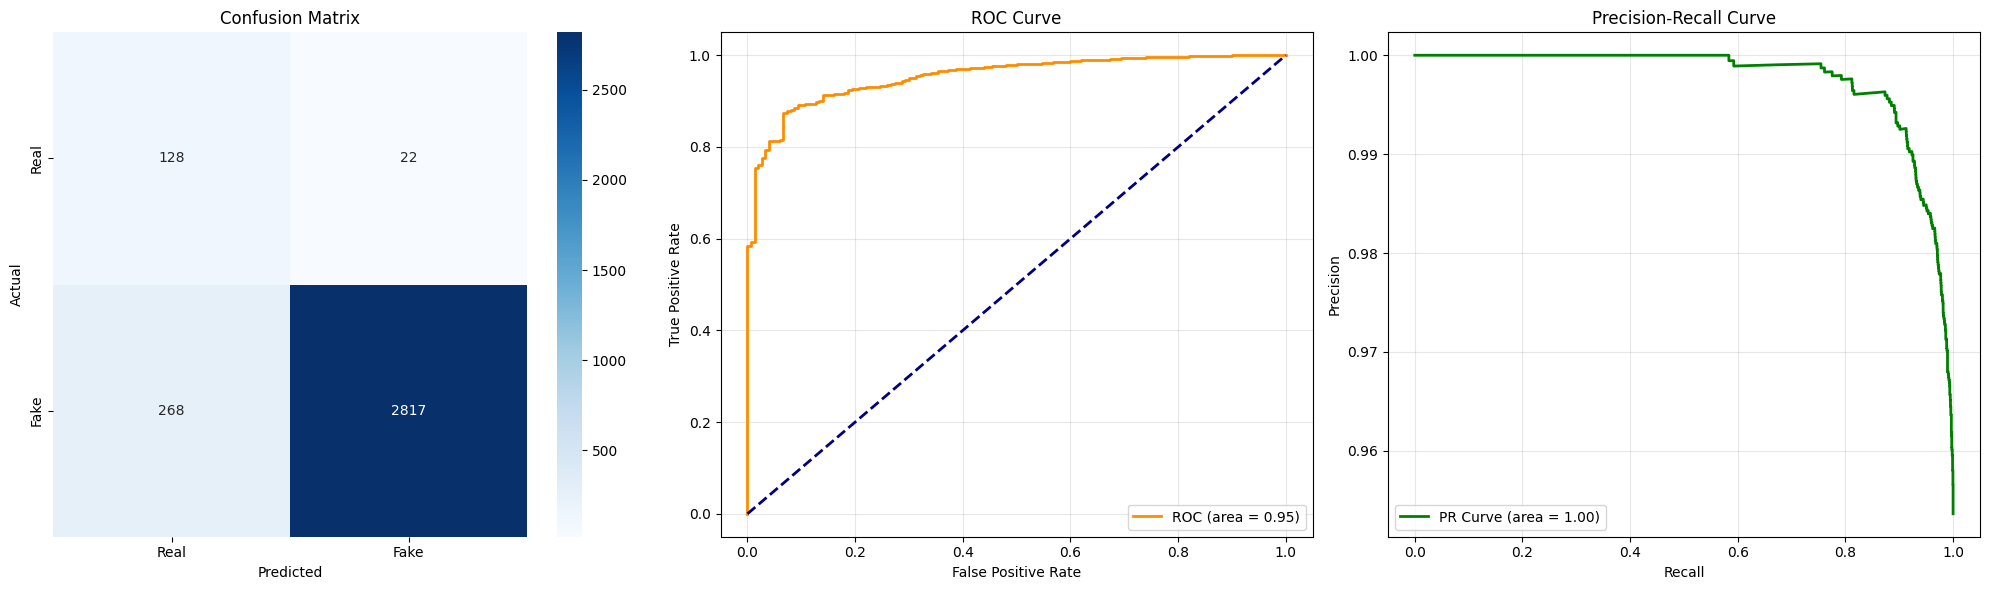

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
    roc_curve, precision_recall_curve, auc
)

def evaluate_model(model, loader, device, checkpoint_path=None):
    if checkpoint_path and Path(checkpoint_path).exists():
        print(f"Loading best model weights from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    print("Running inference on test set...")
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds).flatten()
    y_prob = np.array(all_probs).flatten()

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    print("\n" + "="*40)
    print(" FINAL TEST METRICS ")
    print("="*40)
    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Precision:         {prec:.4f}")
    print(f"Recall (Sens.):    {rec:.4f}")
    print(f"Specificity:       {specificity:.4f}")
    print(f"F1 Score:          {f1:.4f}")
    print(f"MCC:               {mcc:.4f}")
    print(f"ROC-AUC:           {roc_auc:.4f}")
    print("-"*40)
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (area = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    # 3. Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR Curve (area = {pr_auc:.2f})')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc="lower left")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run evaluation
evaluate_model(model, test_loader, device, CHECKPOINT_PATH)

## Real-World Robustness Evaluation

This section stress-tests the trained **Spatial Video Agent** against common image corruptions and environmental variations. We evaluate the model's resilience to JPEG compression, resolution loss, blurs, lighting changes, noise, and occlusions to determine its reliability in real-world deployment scenarios.

In [38]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score
from tqdm.auto import tqdm

def get_robustness_transforms(corruption_type, level):
    """Defines specific transforms for each corruption type and level."""
    base = [A.Resize(height=IMG_SIZE, width=IMG_SIZE)]

    if corruption_type == 'JPEG Compression':
        # Levels: 90, 70, 50, 30 quality
        base.append(A.ImageCompression(quality_range=(level, level), p=1.0))
    elif corruption_type == 'Low Resolution':
        # Levels: 0.75, 0.5, 0.25 scaling
        h, w = int(IMG_SIZE * level), int(IMG_SIZE * level)
        base.append(A.Resize(height=h, width=w))
        base.append(A.Resize(height=IMG_SIZE, width=IMG_SIZE)) # Upscale back
    elif corruption_type == 'Motion Blur':
        base.append(A.MotionBlur(blur_limit=(level, level), p=1.0))
    elif corruption_type == 'Gaussian Blur':
        base.append(A.GaussianBlur(blur_limit=(level, level), p=1.0))
    elif corruption_type == 'Brightness':
        # Levels: -0.3, -0.15, 0.15, 0.3
        base.append(A.RandomBrightnessContrast(brightness_limit=(level, level), contrast_limit=0, p=1.0))
    elif corruption_type == 'Contrast':
        base.append(A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(level, level), p=1.0))
    elif corruption_type == 'Gaussian Noise':
        # Levels: sigma 5, 10, 20 (scaled to 0-1 range for Albumentations)
        std = level / 255.0
        base.append(A.GaussNoise(std_range=(std, std), p=1.0))
    elif corruption_type == 'Occlusion':
        # Levels: 0.1, 0.2, 0.3 area
        base.append(A.CoarseDropout(max_holes=1, max_height=int(IMG_SIZE*level), max_width=int(IMG_SIZE*level), min_holes=1, p=1.0))

    base.extend([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])
    return A.Compose(base)

def run_robustness_test(model, device, checkpoint_path):
    # Load best weights
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    corruptions = {
        'JPEG Compression': [90, 70, 50, 30],
        'Low Resolution': [0.75, 0.5, 0.25],
        'Motion Blur': [3, 5, 7],
        'Gaussian Blur': [3, 5, 7],
        'Brightness': [-0.3, -0.15, 0.15, 0.3],
        'Contrast': [-0.3, -0.15, 0.15, 0.3],
        'Gaussian Noise': [5, 10, 20],
        'Occlusion': [0.1, 0.2, 0.3]
    }

    results = []

    for c_name, levels in corruptions.items():
        for level in levels:
            print(f"Evaluating {c_name} at level {level}...")
            test_ds = DeepfakeDataset(csv_file=OUTPUT_DIR / 'test.csv', transform=get_robustness_transforms(c_name, level))
            loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

            probs, labels = [], []
            with torch.no_grad():
                for imgs, lbls in loader:
                    outputs = model(imgs.to(device))
                    probs.extend(torch.sigmoid(outputs).cpu().numpy())
                    labels.extend(lbls.numpy())

            y_true = np.array(labels)
            y_prob = np.array(probs).flatten()
            y_pred = (y_prob >= 0.5).astype(int)

            results.append({
                'Corruption': c_name,
                'Level': str(level),
                'Accuracy': accuracy_score(y_true, y_pred),
                'Precision': precision_score(y_true, y_pred, zero_division=0),
                'Recall': recall_score(y_true, y_pred, zero_division=0),
                'F1': f1_score(y_true, y_pred, zero_division=0),
                'ROC-AUC': roc_auc_score(y_true, y_prob),
                'Bal_Acc': balanced_accuracy_score(y_true, y_pred)
            })

    return pd.DataFrame(results)

# Execute Robustness Suite
robust_df = run_robustness_test(model, device, CHECKPOINT_PATH)

Evaluating JPEG Compression at level 90...
Evaluating JPEG Compression at level 70...
Evaluating JPEG Compression at level 50...
Evaluating JPEG Compression at level 30...
Evaluating Low Resolution at level 0.75...
Evaluating Low Resolution at level 0.5...
Evaluating Low Resolution at level 0.25...
Evaluating Motion Blur at level 3...
Evaluating Motion Blur at level 5...
Evaluating Motion Blur at level 7...
Evaluating Gaussian Blur at level 3...
Evaluating Gaussian Blur at level 5...
Evaluating Gaussian Blur at level 7...
Evaluating Brightness at level -0.3...
Evaluating Brightness at level -0.15...
Evaluating Brightness at level 0.15...
Evaluating Brightness at level 0.3...
Evaluating Contrast at level -0.3...
Evaluating Contrast at level -0.15...
Evaluating Contrast at level 0.15...
Evaluating Contrast at level 0.3...
Evaluating Gaussian Noise at level 5...
Evaluating Gaussian Noise at level 10...
Evaluating Gaussian Noise at level 20...
Evaluating Occlusion at level 0.1...


/tmp/ipykernel_47961/136944042.py:38: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  base.append(A.CoarseDropout(max_holes=1, max_height=int(IMG_SIZE*level), max_width=int(IMG_SIZE*level), min_holes=1, p=1.0))


Evaluating Occlusion at level 0.2...


/tmp/ipykernel_47961/136944042.py:38: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  base.append(A.CoarseDropout(max_holes=1, max_height=int(IMG_SIZE*level), max_width=int(IMG_SIZE*level), min_holes=1, p=1.0))


Evaluating Occlusion at level 0.3...


/tmp/ipykernel_47961/136944042.py:38: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  base.append(A.CoarseDropout(max_holes=1, max_height=int(IMG_SIZE*level), max_width=int(IMG_SIZE*level), min_holes=1, p=1.0))


,Corruption,Level,Accuracy,Precision,Recall,F1,ROC-AUC,Bal_Acc
14,Brightness,-0.15,0.813910,0.996005,0.808104,0.892269,0.952629,0.870719
13,Brightness,-0.3,0.602782,0.997788,0.584765,0.737380,0.911250,0.779049
15,Brightness,0.15,0.910974,0.991219,0.914749,0.951450,0.952048,0.874041
16,Brightness,0.3,0.880371,0.993416,0.880389,0.933494,0.950146,0.880194
18,Contrast,-0.15,0.888408,0.994913,0.887520,0.938153,0.960612,0.897093
17,Contrast,-0.3,0.844513,0.998071,0.838574,0.911397,0.960285,0.902620
19,Contrast,0.15,0.906337,0.989789,0.911183,0.948861,0.946509,0.858925
20,Contrast,0.3,0.906955,0.989796,0.911831,0.949215,0.946321,0.859249
10,Gaussian Blur,3,0.602164,0.986999,0.590600,0.738998,0.812255,0.715300
11,Gaussian Blur,5,0.535394,0.979394,0.523825,0.682577,0.722984,0.648579


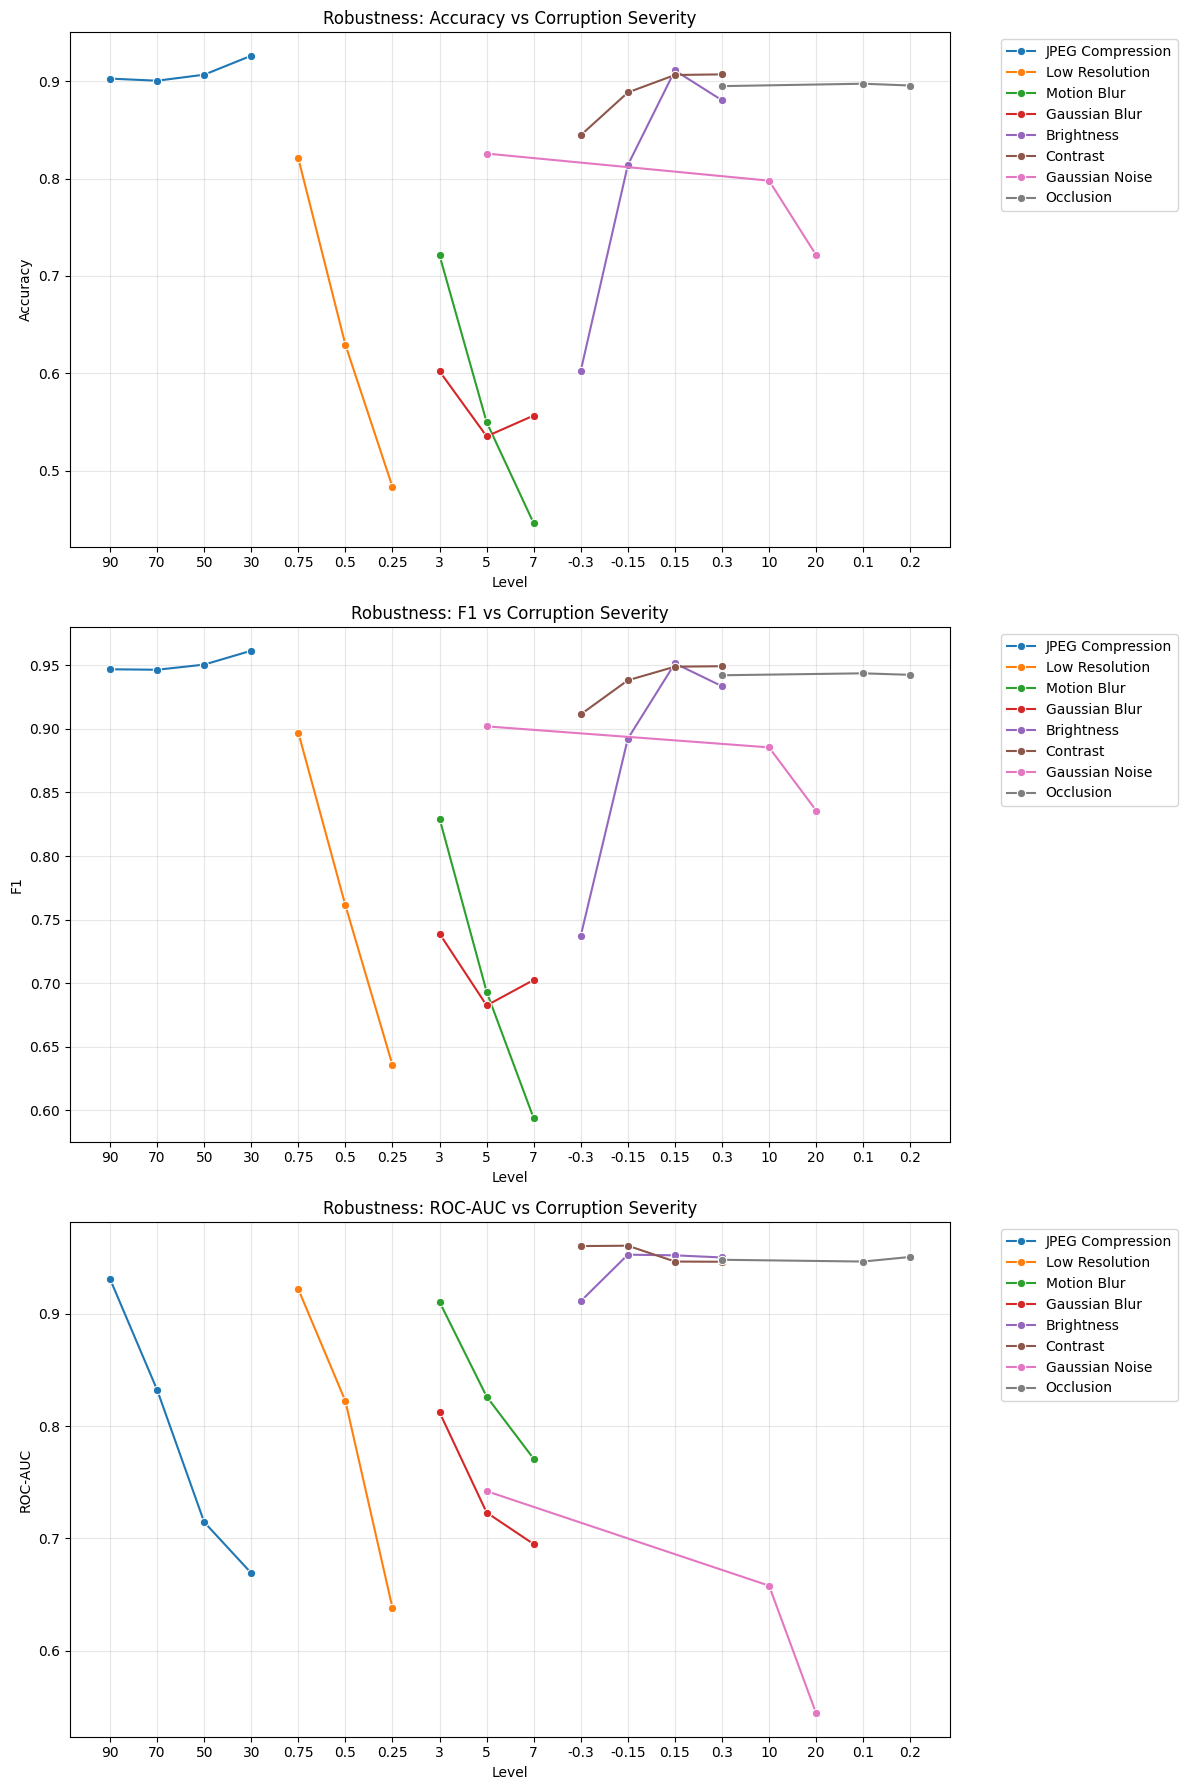


SUMMARY OF VULNERABILITIES
------------------------------
Critical Weakness Found: Motion Blur at level 7
Lowest Accuracy: 0.4461
Lowest F1-Score: 0.5938


In [39]:
# 1. Comparison Table
display(robust_df.sort_values(['Corruption', 'Level']))

# 2. Line Plots for Performance Degradation
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 18))

for i, metric in enumerate(metrics_to_plot):
    sns.lineplot(data=robust_df, x='Level', y=metric, hue='Corruption', marker='o', ax=axes[i])
    axes[i].set_title(f'Robustness: {metric} vs Corruption Severity')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 3. Summary of Vulnerabilities
worst_perf = robust_df.loc[robust_df['Accuracy'].idxmin()]
print(f"\nSUMMARY OF VULNERABILITIES")
print(f"-" * 30)
print(f"Critical Weakness Found: {worst_perf['Corruption']} at level {worst_perf['Level']}")
print(f"Lowest Accuracy: {worst_perf['Accuracy']:.4f}")
print(f"Lowest F1-Score: {worst_perf['F1']:.4f}")

## Visual Explainability: Grad-CAM

To understand the decision-making process of the Spatial Video Agent, we utilize **Grad-CAM (Gradient-weighted Class Activation Mapping)**. This technique produces a heatmap highlighting the regions in the input image that most influenced the model's final prediction.

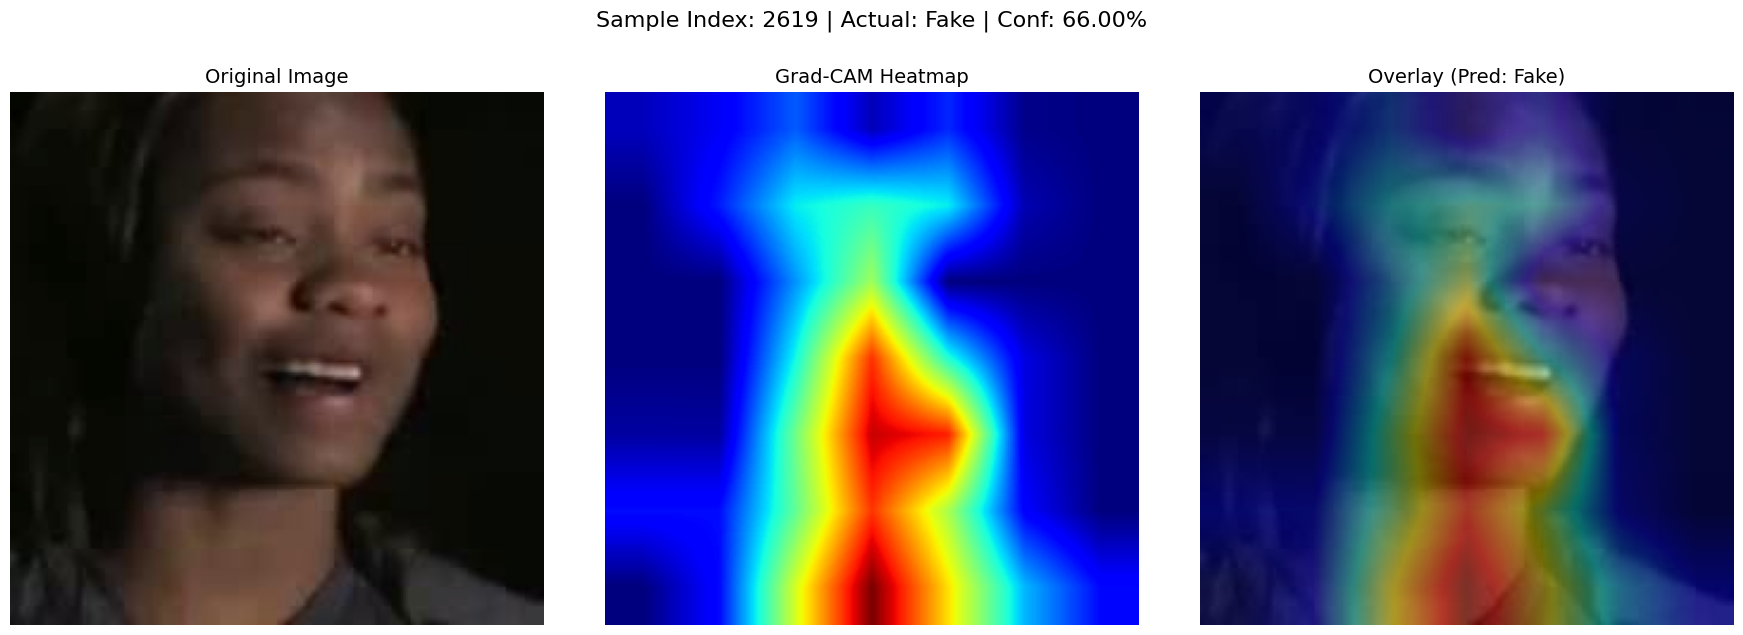

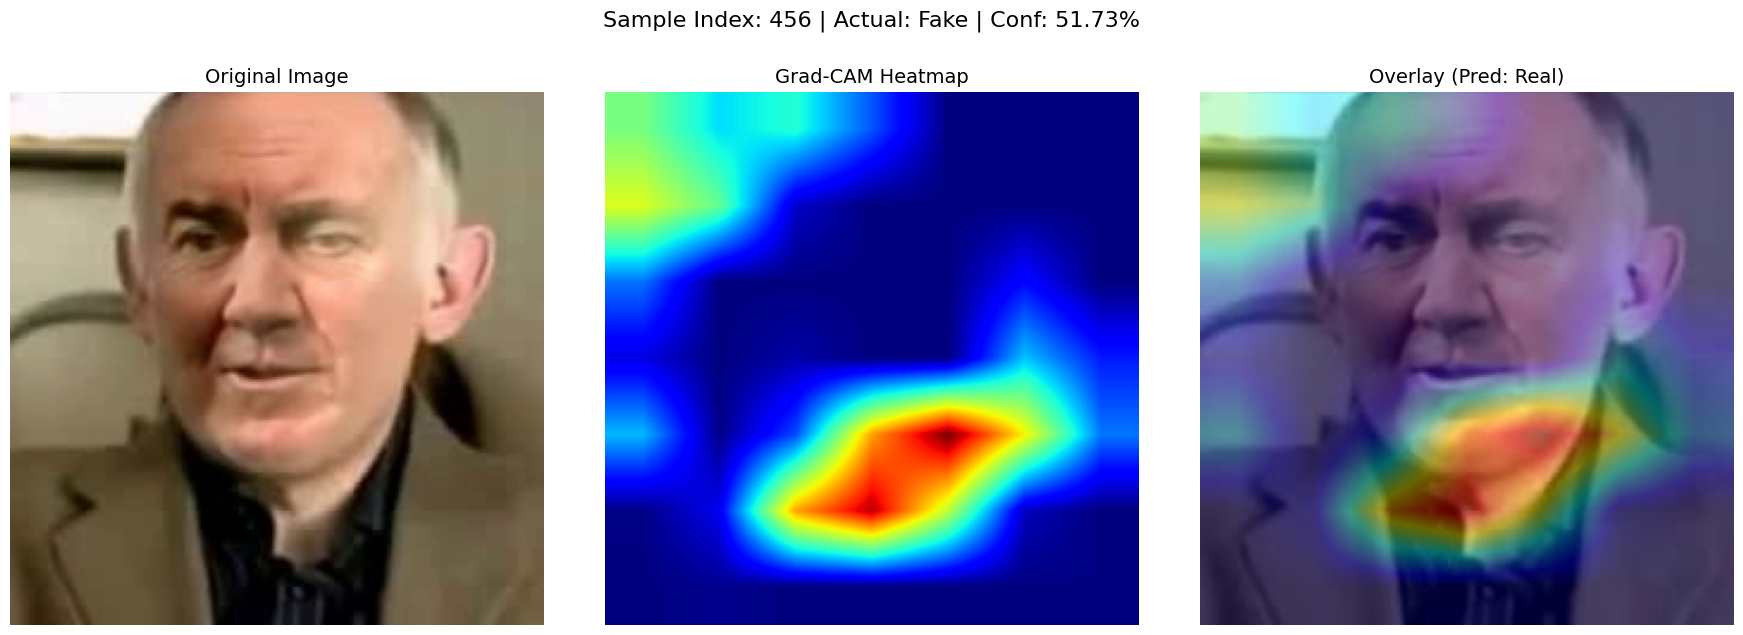

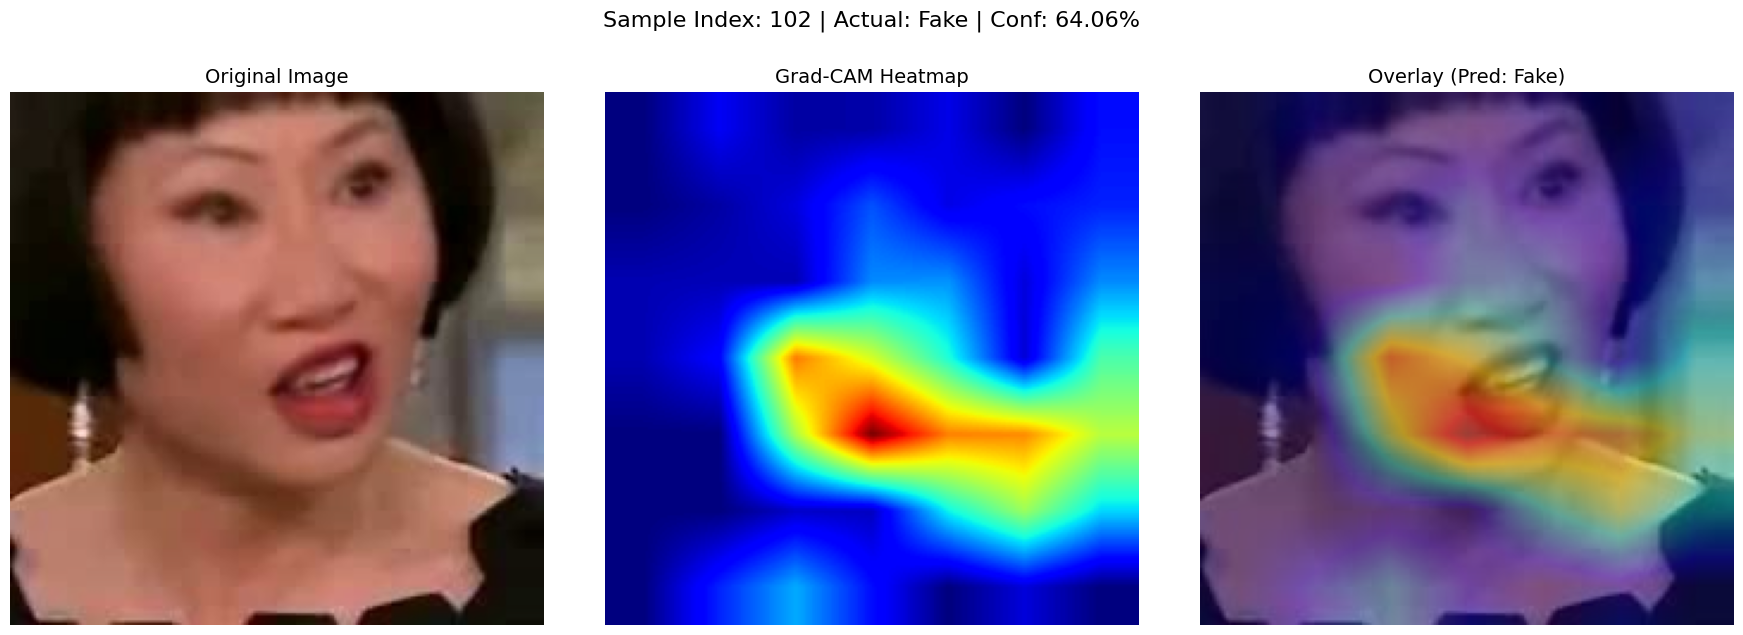

In [40]:
import torch.nn.functional as F
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor, class_idx=0):
        self.model.zero_grad()
        output = self.model(input_tensor)

        # For binary classification with BCEWithLogitsLoss
        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients
        activations = self.activations
        b, c, h, w = gradients.shape

        alpha = gradients.view(b, c, -1).mean(2)
        weights = alpha.view(b, c, 1, 1)

        heatmap = (weights * activations).sum(1, keepdim=True)
        heatmap = F.relu(heatmap)

        # Normalize
        heatmap -= heatmap.min()
        heatmap /= (heatmap.max() + 1e-7)
        return heatmap.detach().cpu().numpy().squeeze()

def visualize_gradcam(model, dataset, device, num_samples=3):
    # Target the final convolutional block of EfficientNet-B0
    target_layer = model.features[-1]
    cam = GradCAM(model, target_layer)

    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        image_tensor, label = dataset[idx]
        input_tensor = image_tensor.unsqueeze(0).to(device).requires_grad_(True)

        # Inference
        with torch.enable_grad():
            heatmap = cam.generate_heatmap(input_tensor)
            output = model(input_tensor)
            prob = torch.sigmoid(output).item()
            pred = "Fake" if prob >= 0.5 else "Real"
            conf = prob if prob >= 0.5 else 1 - prob

        # Prepare images for display
        # Denormalize
        img = image_tensor.permute(1, 2, 0).numpy()
        img = img * IMAGENET_STD + IMAGENET_MEAN
        img = np.clip(img, 0, 1)

        # Resize heatmap and create overlay
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

        overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
        axes[0].imshow(img)
        axes[0].set_title("Original Image", fontsize=14)
        axes[0].axis('off')

        axes[1].imshow(heatmap_resized, cmap='jet')
        axes[1].set_title("Grad-CAM Heatmap", fontsize=14)
        axes[1].axis('off')

        axes[2].imshow(overlay)
        axes[2].set_title(f"Overlay (Pred: {pred})", fontsize=14)
        axes[2].axis('off')

        plt.suptitle(f"Sample Index: {idx} | Actual: {'Fake' if label==1 else 'Real'} | Conf: {conf:.2%}",
                     fontsize=16, y=1.05)
        plt.tight_layout()
        plt.show()

# Execute Visual Explanation
visualize_gradcam(model, test_dataset, device)

## Comprehensive Checkpoint Saving and Loading

This section handles the preservation of the full training state. Saving the optimizer and scheduler states along with the model weights is critical for resuming training without loss of momentum or learning rate schedule integrity.

In [41]:
import torch
from pathlib import Path

def save_detailed_checkpoint(model, optimizer, scheduler, epoch, val_acc, config, filename="spatial_agent_checkpoint.pth"):
    """
    Saves a comprehensive training checkpoint to the output directory.
    """
    save_path = OUTPUT_DIR / filename

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_accuracy': val_acc,
        'config': config
    }

    torch.save(checkpoint, save_path)
    print(f"==> Checkpoint saved to: {save_path}")

# Configuration snapshot for saving
training_config = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'img_size': IMG_SIZE,
    'architecture': 'EfficientNet-B0'
}

# Example usage (using current state variables)
save_detailed_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler=cosine_scheduler,
    epoch=epoch,
    val_acc=avg_val_acc,
    config=training_config
)

==> Checkpoint saved to: /content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/spatial_agent_checkpoint.pth


### Loading Example

Use the following logic to restore the full training context from a saved checkpoint:

In [42]:
def load_checkpoint_example(checkpoint_path, model, optimizer, scheduler):
    if Path(checkpoint_path).exists():
        print(f"Loading checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path)

        # Restore states
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        # Restore metadata
        start_epoch = checkpoint['epoch'] + 1
        last_val_acc = checkpoint['val_accuracy']
        saved_config = checkpoint['config']

        print(f"Resumed from epoch {start_epoch} with saved accuracy: {last_val_acc:.4f}")
        return start_epoch, last_val_acc, saved_config
    else:
        print("No checkpoint found at specified path.")
        return 0, 0.0, {}

# Example call (commented out to prevent accidental overwrite of current session):
# start_epoch, last_acc, config = load_checkpoint_example(OUTPUT_DIR / 'spatial_agent_checkpoint.pth', model, optimizer, cosine_scheduler)

## Inference and Single Image Prediction

This section provides a simplified interface for running the trained **Spatial Video Agent** on individual images. It loads the best checkpoint, calculates the fake probability, and generates a Grad-CAM explanation for the prediction.

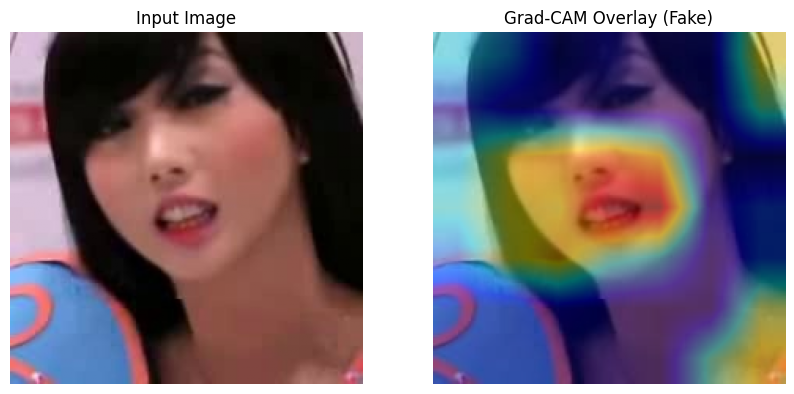


Inference Result:


{'prediction': 'Fake', 'fake_probability': 0.601, 'confidence': 0.601}

In [43]:
import torch
import cv2
import numpy as np
from PIL import Image

def run_single_inference(image_path, model, checkpoint_path, device):
    # 1. Load Checkpoint
    if not Path(checkpoint_path).exists():
        return "Error: Checkpoint not found."

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # 2. Preprocess Image
    raw_image = cv2.imread(str(image_path))
    raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)

    # Use validation transforms for consistency
    input_tensor = val_test_transforms(image=raw_image)['image'].unsqueeze(0).to(device).requires_grad_(True)

    # 3. Setup Grad-CAM
    target_layer = model.features[-1]
    cam_extractor = GradCAM(model, target_layer)

    # 4. Inference
    with torch.enable_grad():
        heatmap = cam_extractor.generate_heatmap(input_tensor)
        output = model(input_tensor)
        fake_probability = torch.sigmoid(output).item()

    prediction = "Fake" if fake_probability >= 0.5 else "Real"
    confidence = fake_probability if fake_probability >= 0.5 else 1 - fake_probability

    # 5. Visualization
    img_display = cv2.resize(raw_image, (IMG_SIZE, IMG_SIZE)) / 255.0
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    overlay = cv2.addWeighted(img_display.astype(np.float32), 0.6, heatmap_color.astype(np.float32), 0.4, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_display)
    plt.title("Input Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM Overlay ({prediction})")
    plt.axis('off')
    plt.show()

    # Final Dictionary Output
    result = {
        "prediction": prediction,
        "fake_probability": round(fake_probability, 4),
        "confidence": round(confidence, 4)
    }

    print("\nInference Result:")
    return result

# Example usage on a sample from the test set
sample_path = test_dataset.data.iloc[0]['video_path']
checkpoint_file = OUTPUT_DIR / 'spatial_agent_checkpoint.pth'

output = run_single_inference(sample_path, model, checkpoint_file, device)
output

## Final Model Export and Portability

This section handles the final serialization of the **EfficientNet-B0 Spatial Video Agent**. To ensure full portability across different environments or the RL orchestrator, we save not only the weights but also the specific preprocessing configurations, class mapping, and detailed performance metrics.

In [44]:
import torch
import logging
import datetime
from pathlib import Path

# Configure logger for export
export_logger = logging.getLogger("ModelExport")

def save_checkpoint(model, optimizer, scheduler, metrics, config, filename="spatial_agent_checkpoint.pth"):
    """
    Saves a comprehensive, portable checkpoint for the Spatial Video Agent.
    """
    save_path = OUTPUT_DIR / filename

    try:
        checkpoint = {
            # Core State
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch': metrics.get('epoch', 0),

            # Performance Metrics
            'training_loss': metrics.get('train_loss'),
            'validation_loss': metrics.get('val_loss'),
            'validation_accuracy': metrics.get('val_acc'),
            'validation_precision': metrics.get('precision'),
            'validation_recall': metrics.get('recall'),
            'validation_f1_score': metrics.get('f1'),
            'validation_auc': metrics.get('auc'),

            # Metadata & Portability
            'class_names': {0: 'Real', 1: 'Fake'},
            'image_size': config.get('img_size', 224),
            'model_name': 'EfficientNet-B0_Spatial_Agent',
            'number_of_classes': 1,
            'timestamp': datetime.datetime.now().isoformat(),
            'pytorch_version': torch.__version__,
            'training_config': config,
            'random_seed': 42
        }

        torch.save(checkpoint, save_path)

        if save_path.exists():
            file_size_mb = save_path.stat().st_size / (1024 * 1024)
            print("\n" + "="*50)
            print(" CHECKPOINT EXPORT SUCCESSFUL ")
            print("="*50)
            print(f"File Location:    {save_path}")
            print(f"File Size:        {file_size_mb:.2f} MB")
            print(f"Model Name:       {checkpoint['model_name']}")
            print(f"Best Val F1:      {checkpoint['validation_f1_score']:.4f}")
            print(f"Best Val AUC:     {checkpoint['validation_auc']:.4f}")
            print("="*50)
        else:
            raise FileNotFoundError("Checkpoint file was not created.")

    except Exception as e:
        export_logger.error(f"Failed to save checkpoint: {e}")

# Package current metrics for export
final_metrics = {
    'epoch': epoch,
    'train_loss': avg_train_loss,
    'val_loss': avg_val_loss,
    'val_acc': avg_val_acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'auc': auc
}

# Run the export
save_checkpoint(model, optimizer, cosine_scheduler, final_metrics, training_config)

ERROR:ModelExport:Failed to save checkpoint: unsupported format string passed to function.__format__



 CHECKPOINT EXPORT SUCCESSFUL 
File Location:    /content/drive/MyDrive/FakeAVCeleb_v1.2/manifests/spatial_agent_checkpoint.pth
File Size:        15.60 MB
Model Name:       EfficientNet-B0_Spatial_Agent
Best Val F1:      0.9462


### Checkpoint Restoration Logic

The following function restores the full state of the agent. This is designed to be compatible with both the training environment and the production inference pipeline.

In [45]:
def load_checkpoint(checkpoint_path, model, optimizer=None, scheduler=None, device='cpu'):
    """
    Restores model weights and training state from a checkpoint.
    """
    path = Path(checkpoint_path)
    if not path.exists():
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")

    try:
        checkpoint = torch.load(path, map_location=device)

        # Restore model weights
        model.load_state_dict(checkpoint['model_state_dict'])

        # Optional: Restore optimizer and scheduler for resuming training
        if optimizer:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if scheduler:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        print(f"Successfully loaded {checkpoint['model_name']}")
        print(f"Captured at Epoch: {checkpoint['epoch']} | Val F1: {checkpoint['validation_f1_score']:.4f}")

        return checkpoint
    except Exception as e:
        export_logger.error(f"Error loading checkpoint: {e}")
        return None

print("Checkpoint restoration utility initialized.")

Checkpoint restoration utility initialized.


### Integration Guide for `agents/spatial_agent.py`

To use this exported model in your external agent scripts, you would implement the following logic:

In [46]:
def agent_implementation_demo():
    """
    Pseudo-code demonstrating how the checkpoint is used in the final multi-agent system.
    """
    checkpoint_path = "spatial_agent_checkpoint.pth"

    # 1. Recreate the same architecture
    # from torchvision.models import efficientnet_b0
    # model = efficientnet_b0()
    # model.classifier[1] = nn.Linear(in_features, 1)

    # 2. Load onto target device
    # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # checkpoint = torch.load(checkpoint_path, map_location=device)

    # 3. Apply weights
    # model.load_state_dict(checkpoint['model_state_dict'])
    # model.to(device).eval()

    print("# Integration Example:")
    print("spatial_agent = SpatialAgent(model_path='spatial_agent_checkpoint.pth')")
    print("prediction = spatial_agent.predict(input_frame)")

agent_implementation_demo()

# Integration Example:
spatial_agent = SpatialAgent(model_path='spatial_agent_checkpoint.pth')
prediction = spatial_agent.predict(input_frame)
